In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


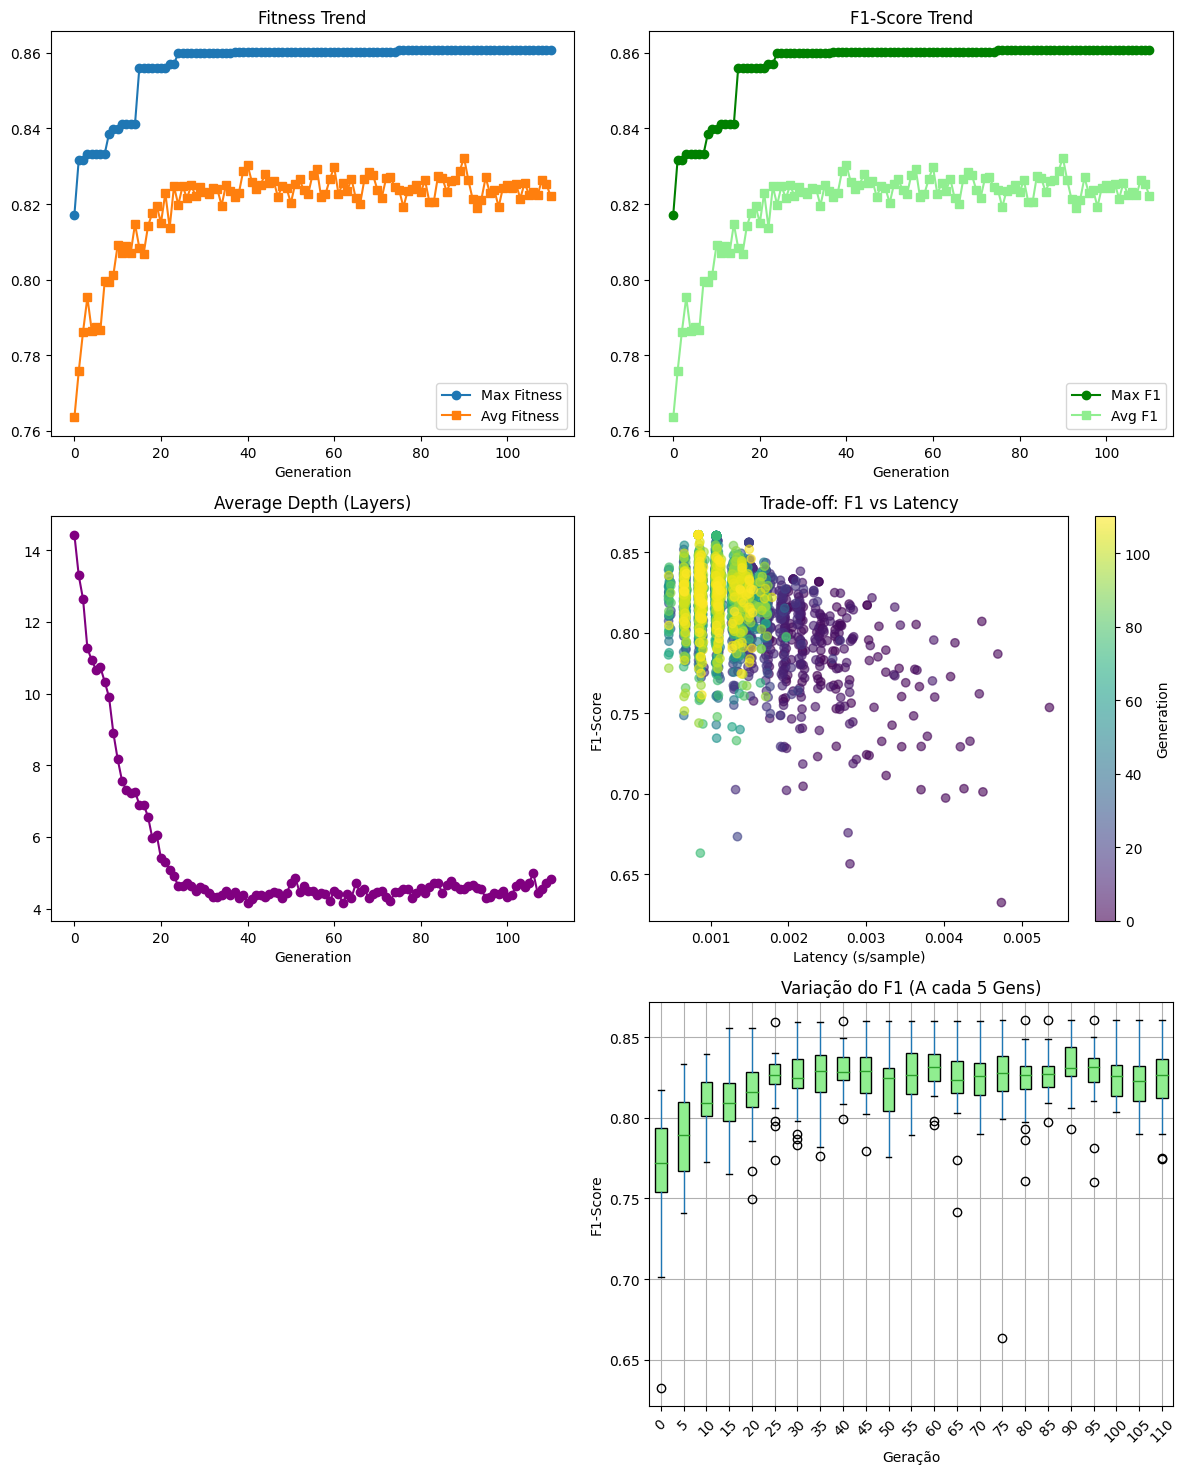

In [2]:

# Carregar os dados
df = pd.read_csv('results_run_1_seed_42_200_steps.csv')

# Agregação por geração
gen_agg = df.groupby('generation').agg({
    'fitness': ['max', 'mean'],
    'f1': ['max', 'mean'],
    'latency': 'mean',
    'depth': 'mean'
}).reset_index()

# Aumentei a altura (15) para caberem as 3 linhas de gráficos
plt.figure(figsize=(12, 15))

# 1. Tendência de Fitness
plt.subplot(3, 2, 1)
plt.plot(gen_agg['generation'], gen_agg['fitness']['max'], label='Max Fitness', marker='o')
plt.plot(gen_agg['generation'], gen_agg['fitness']['mean'], label='Avg Fitness', marker='s')
plt.title('Fitness Trend')
plt.xlabel('Generation')
plt.legend()

# 2. Tendência de F1-Score
plt.subplot(3, 2, 2)
plt.plot(gen_agg['generation'], gen_agg['f1']['max'], label='Max F1', marker='o', color='green')
plt.plot(gen_agg['generation'], gen_agg['f1']['mean'], label='Avg F1', marker='s', color='lightgreen')
plt.title('F1-Score Trend')
plt.xlabel('Generation')
plt.legend()

# 3. Profundidade Média
plt.subplot(3, 2, 3)
plt.plot(gen_agg['generation'], gen_agg['depth'], label='Avg Depth', marker='o', color='purple')
plt.title('Average Depth (Layers)')
plt.xlabel('Generation')

# 4. Trade-off F1 vs Latency
plt.subplot(3, 2, 4)
scatter = plt.scatter(df['latency'], df['f1'], c=df['generation'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Generation')
plt.title('Trade-off: F1 vs Latency')
plt.xlabel('Latency (s/sample)')
plt.ylabel('F1-Score')

# 5. Evolução da Variância do F1
plt.subplot(3, 2, 6)

# Filtramos o DataFrame: gerações onde o resto da divisão por 5 é zero
df_filtered = df[df['generation'] % 5 == 0]

# Usamos o boxplot do pandas agrupando por geração
df_filtered.boxplot(column='f1', by='generation', ax=plt.gca(), 
                    patch_artist=True, 
                    boxprops=dict(facecolor='lightgreen', color='black'))

plt.title('Variação do F1 (A cada 5 Gens)')
plt.suptitle('') # Remove o título automático chato do pandas
plt.xlabel('Geração')
plt.ylabel('F1-Score')

# Ajuste visual para não amontoar os números no eixo X
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

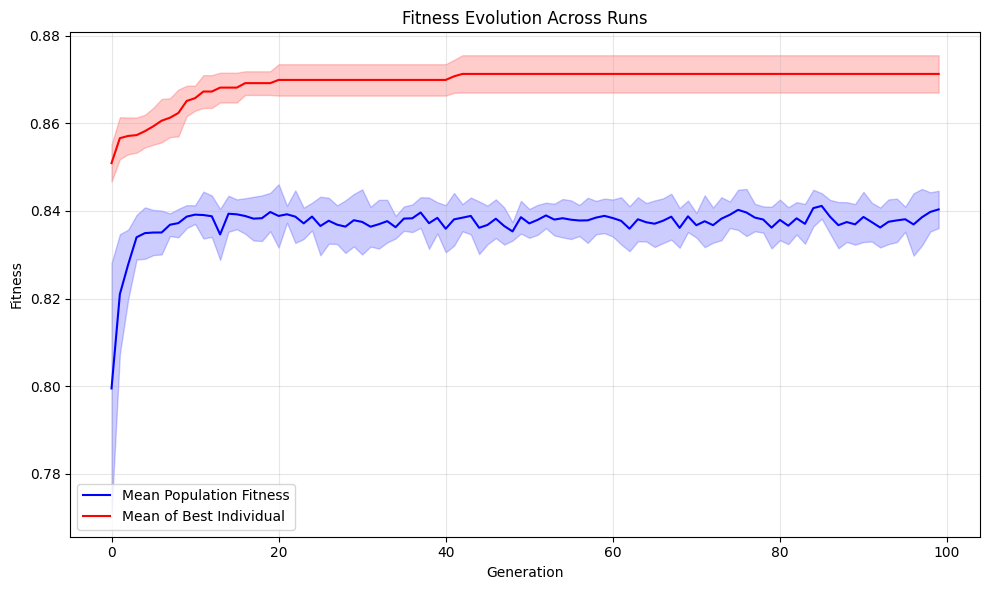

In [3]:
base_path = '../data/agnews/200_steps/evolution/'
seeds = [42, 123, 999, 2024, 7]
run_ids = [1, 2, 3, 4, 5]

# Dicionários para guardar os valores agregados por geração (todas as runs)
pop_mean_dict = {}   # {geração: [media_pop_run1, media_pop_run2, ...]}
best_dict = {}       # {geração: [best_run1, best_run2, ...]}

for run_id, seed in zip(run_ids, seeds):
    filename = f"{base_path}results_run_{run_id}_seed_{seed}_200_steps.csv"
    df = pd.read_csv(filename)
    
    # Por cada geração, obtém a fitness média da população e o máximo
    gen_data = df.groupby('generation')['fitness'].agg(['mean', 'max'])
    
    for gen, row in gen_data.iterrows():
        pop_mean_dict.setdefault(gen, []).append(row['mean'])
        best_dict.setdefault(gen, []).append(row['max'])


generations = sorted(pop_mean_dict.keys())
pop_means = [np.mean(pop_mean_dict[g]) for g in generations]
pop_stds = [np.std(pop_mean_dict[g]) for g in generations]
best_means = [np.mean(best_dict[g]) for g in generations]
best_stds = [np.std(best_dict[g]) for g in generations]

plt.figure(figsize=(10, 6))

plt.plot(generations, pop_means, label='Mean Population Fitness', color='blue')
plt.fill_between(generations,
                 np.array(pop_means) - np.array(pop_stds),
                 np.array(pop_means) + np.array(pop_stds),
                 alpha=0.2, color='blue')

plt.plot(generations, best_means, label='Mean of Best Individual', color='red')
plt.fill_between(generations,
                 np.array(best_means) - np.array(best_stds),
                 np.array(best_means) + np.array(best_stds),
                 alpha=0.2, color='red')

plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Fitness Evolution Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{base_path}fitness_all_runs.png', dpi=150)
plt.show()